In [1]:
import pandas as pd
df=pd.read_csv("vgsales.csv")

In [2]:
df.shape

(16327, 11)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16327 entries, 0 to 16326
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16327 non-null  int64  
 1   Name          16327 non-null  object 
 2   Platform      16327 non-null  object 
 3   Year          16327 non-null  int64  
 4   Genre         16327 non-null  object 
 5   Publisher     16291 non-null  object 
 6   NA_Sales      16327 non-null  float64
 7   EU_Sales      16327 non-null  float64
 8   JP_Sales      16327 non-null  float64
 9   Other_Sales   16327 non-null  float64
 10  Global_Sales  16327 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 1.4+ MB


In [4]:
df.describe()[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales", "Global_Sales"]]

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16327.000000,16327.000000,16327.000000,16327.000000,16327.000000
mean,0.265415,0.147554,0.078661,0.048325,0.540232
std,0.821591,0.508766,0.311557,0.189885,1.565732
min,0.000000,0.000000,0.000000,0.000000,0.010000
25%,0.000000,0.000000,0.000000,0.000000,0.060000
50%,0.080000,0.020000,0.000000,0.010000,0.170000
75%,0.240000,0.110000,0.040000,0.040000,0.480000
max,41.490000,29.020000,10.220000,10.570000,82.740000


In [5]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [6]:
df.isnull().sum()

Rank             0
Name             0
Platform         0
Year             0
Genre            0
Publisher       36
NA_Sales         0
EU_Sales         0
JP_Sales         0
Other_Sales      0
Global_Sales     0
dtype: int64

In [7]:
df["Publisher"]=df["Publisher"].fillna("Unknown")

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
sorted(df["Year"].unique())

[np.int64(1980),
 np.int64(1981),
 np.int64(1982),
 np.int64(1983),
 np.int64(1984),
 np.int64(1985),
 np.int64(1986),
 np.int64(1987),
 np.int64(1988),
 np.int64(1989),
 np.int64(1990),
 np.int64(1991),
 np.int64(1992),
 np.int64(1993),
 np.int64(1994),
 np.int64(1995),
 np.int64(1996),
 np.int64(1997),
 np.int64(1998),
 np.int64(1999),
 np.int64(2000),
 np.int64(2001),
 np.int64(2002),
 np.int64(2003),
 np.int64(2004),
 np.int64(2005),
 np.int64(2006),
 np.int64(2007),
 np.int64(2008),
 np.int64(2009),
 np.int64(2010),
 np.int64(2011),
 np.int64(2012),
 np.int64(2013),
 np.int64(2014),
 np.int64(2015),
 np.int64(2016),
 np.int64(2017),
 np.int64(2020)]

In [10]:
import numpy as np
df["Year"]=df["Year"].apply(lambda x: x if x>=1980 and x<=2016 else np.nan)

In [11]:
df.isnull().sum()

Rank            0
Name            0
Platform        0
Year            4
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

In [12]:
df=df.dropna(subset=["Year"])

In [13]:
df=df.reset_index(drop=True) #Drop to drop past index

In [14]:
genre_sales=df.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False)

In [15]:
genre_sales

Genre
Action          1722.87
Sports          1309.24
Shooter         1026.20
Role-Playing     923.80
Platform         829.15
Misc             797.62
Racing           726.77
Fighting         444.05
Simulation       389.87
Puzzle           242.22
Adventure        234.80
Strategy         173.43
Name: Global_Sales, dtype: float64

In [16]:
platform_sales=df.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False)
platform_sales

Platform
PS2     1233.46
X360     969.61
PS3      949.35
Wii      909.81
DS       818.67
PS       727.39
GBA      313.56
PSP      291.71
PS4      278.07
PC       255.05
GB       254.42
XB       252.09
NES      251.07
3DS      246.28
N64      218.21
SNES     200.05
GC       197.14
XOne     141.06
2600      86.57
WiiU      81.86
PSV       61.61
SAT       33.59
GEN       28.36
DC        15.97
SCD        1.87
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: Global_Sales, dtype: float64

In [17]:
publisher_sales=df.groupby("Publisher")["Global_Sales"].sum().sort_values(ascending=False)
publisher_sales

Publisher
Nintendo                       1784.43
Electronic Arts                1093.39
Activision                      721.41
Sony Computer Entertainment     607.28
Ubisoft                         473.25
                                ...   
Interchannel-Holon                0.01
Inti Creates                      0.01
Interworks Unlimited, Inc.        0.01
Genterprise                       0.01
Takuyo                            0.01
Name: Global_Sales, Length: 576, dtype: float64

<Axes: title={'center': 'Sales over time'}, xlabel='Year', ylabel='Sales(In Millions)'>

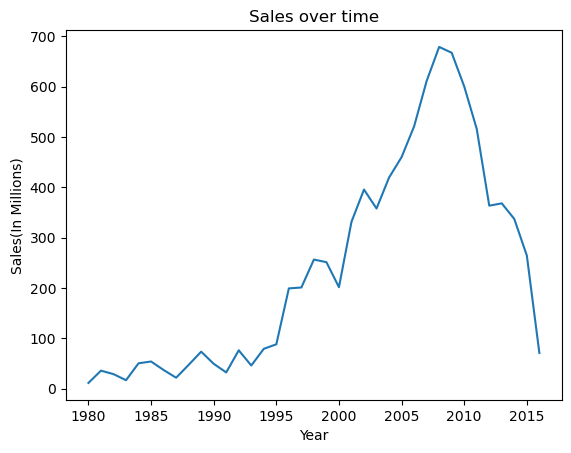

In [18]:
yearly_sales=df.groupby("Year")["Global_Sales"].sum()
yearly_sales.plot(kind="line",title="Sales over time",xlabel="Year",ylabel="Sales(In Millions)")

<Axes: title={'center': 'Sales per region'}, xlabel='region', ylabel='Tatal Sales'>

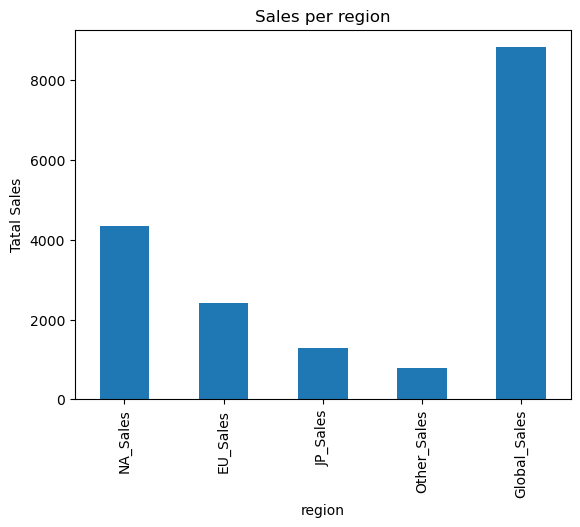

In [19]:
region_totals=df[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales", "Global_Sales"]].sum()
region_totals.plot(kind="bar",title="Sales per region",xlabel="region",ylabel="Tatal Sales")

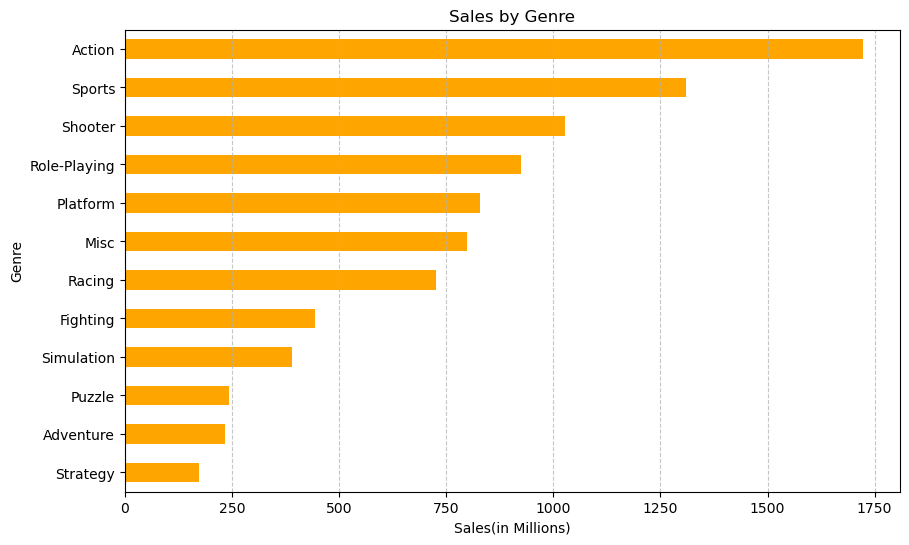

In [20]:
import matplotlib.pyplot as plt
genre_sales=df.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=True)
plt.figure(figsize=(10,6))
genre_sales.plot(kind="barh",color="orange")
plt.title("Sales by Genre")
plt.xlabel("Sales(in Millions)")
plt.ylabel("Genre")
plt.grid(axis="x",linestyle="--",alpha=0.7)
plt.show()

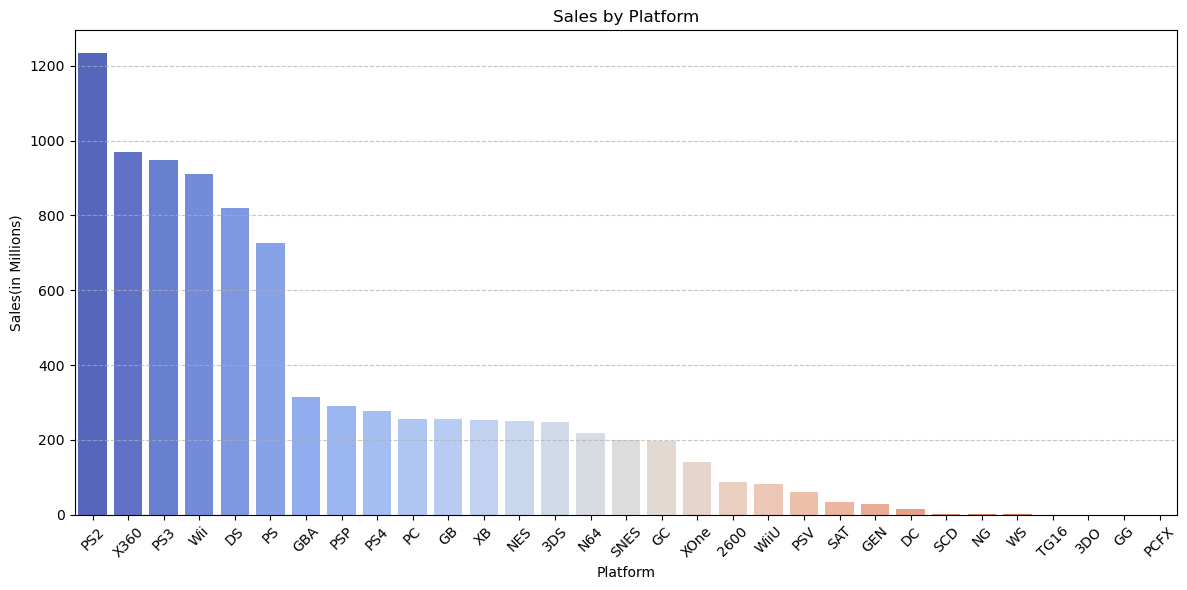

In [21]:
import seaborn as sns
platform_sales=df.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12,6))
sns.barplot(data=platform_sales, x="Platform", y="Global_Sales",hue="Platform", palette ="coolwarm",dodge=False, legend=False)
plt.title("Sales by Platform")
plt.xticks(rotation=45)
plt.ylabel("Sales(in Millions)")
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.tight_layout()
plt.show()

In [22]:
df.groupby("Genre")["Global_Sales"].agg(["sum","mean"]).sort_values(by="sum",ascending=False)

,sum,mean
Genre,,
Action,1722.87,0.529788
Sports,1309.24,0.568247
Shooter,1026.20,0.800468
Role-Playing,923.80,0.628863
Platform,829.15,0.946518
Misc,797.62,0.466444
Racing,726.77,0.592798
Fighting,444.05,0.531160
Simulation,389.87,0.458671


In [23]:
#Pactice
df.groupby(["Genre", "Platform"]).agg({"Global_Sales":"sum","Rank":"mean"})

Global_Sales          Rank
Genre    Platform                            
Action   2600             26.39   4973.472727
         3DS              56.61   9691.222222
         DC                1.26   9011.666667
         DS              114.19   9370.211310
         GB                7.92   5430.833333
...                         ...           ...
Strategy Wii               5.23   9064.760000
         WiiU              1.24   9354.333333
         X360              9.77   7685.518519
         XB                2.78  10876.285714
         XOne              0.38  10675.666667

[293 rows x 2 columns]

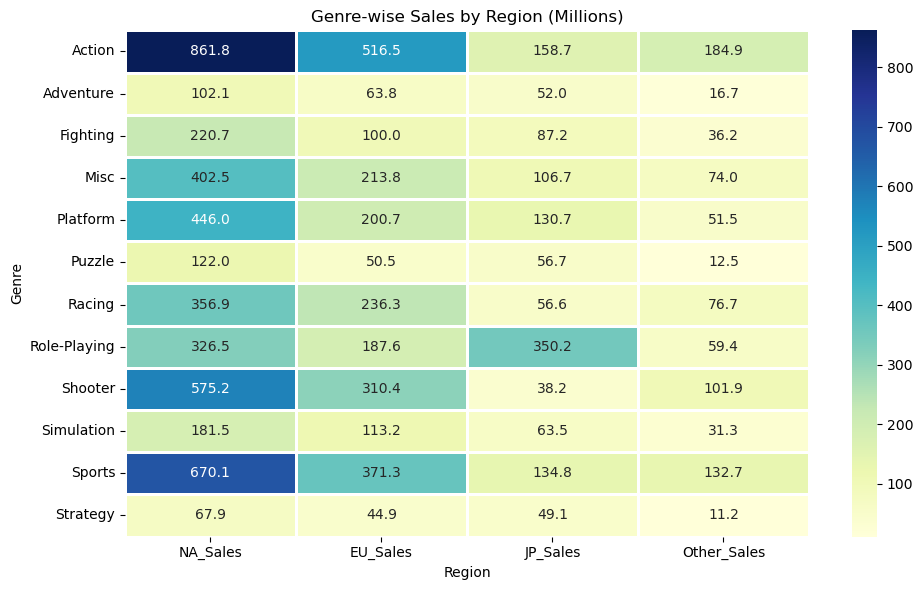

In [24]:
genre_region=df.groupby("Genre")[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].sum()
plt.figure(figsize=(10,6))
sns.heatmap(genre_region,annot=True, fmt='.1f', cmap='YlGnBu', linewidth=1)
plt.title("Genre-wise Sales by Region (Millions)")
plt.xlabel("Region")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

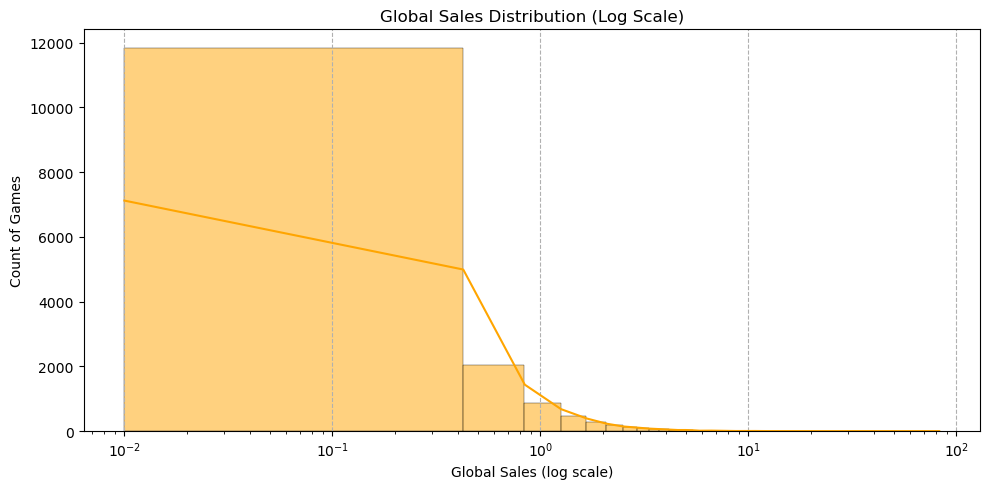

In [25]:
plt.figure(figsize=(10,5))
sns.histplot(df["Global_Sales"],bins=200,kde=True, color="orange")
plt.xscale("log")
plt.title("Global Sales Distribution (Log Scale)")
plt.xlabel("Global Sales (log scale)")
plt.ylabel("Count of Games")
plt.grid(axis="x", linestyle="--", alpha=1)
plt.tight_layout()
plt.show()

In [26]:
#practice to remove outliers
Q1=df["Global_Sales"].quantile(0.25)
Q3=df["Global_Sales"].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
filtered_df=df[(df["Global_Sales"]>=lower_bound) & (df["Global_Sales"]<=upper_bound)]
print(f"Original rows: {df.shape[0]}")
print(f"Filtered rows: {filtered_df.shape[0]}")
print(f"Outliers removed: {df.shape[0] - filtered_df.shape[0]}")

Original rows: 16323
Filtered rows: 14496
Outliers removed: 1827


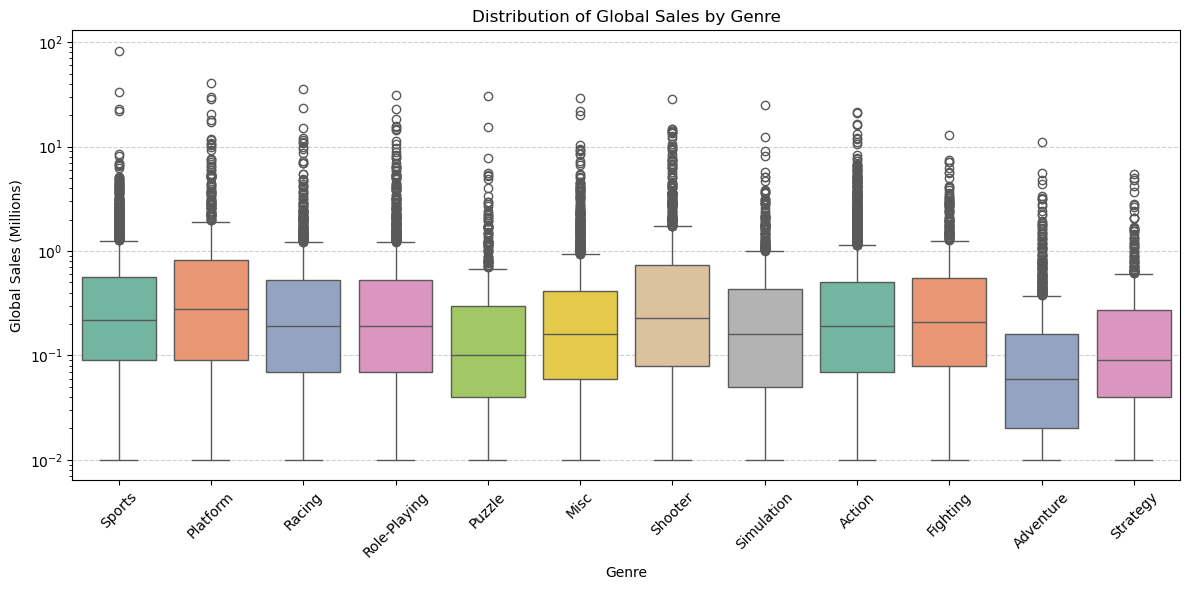

In [27]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df,x="Genre",y="Global_Sales",hue="Genre",palette="Set2")
plt.yscale("log")
plt.title("Distribution of Global Sales by Genre")
plt.xticks(rotation=45)
plt.ylabel("Global Sales (Millions)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [36]:
genre_global_sales=df.groupby("Genre",as_index=False)["Global_Sales"].sum()
genre_global_sales.to_csv("genre_global_sales.csv",index=False)

In [37]:
platform_global_sales=df.groupby("Platform",as_index=False)["Global_Sales"].sum()
platform_global_sales.to_csv("platform_global_sales.csv",index=False)

In [53]:
region_total_sales=df[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].sum().to_frame().reset_index()
region_total_sales.to_csv("region_total_sales.csv",index=False)

In [52]:
sales_by_year=df.groupby("Year",as_index=False)["Global_Sales"].sum().sort_values(by="Year",ascending=True)
sales_by_year.to_csv("sales_by_year.csv",index=False)

In [54]:
publisher_global_sales=df.groupby("Publisher",as_index=False)["Global_Sales"].sum()
publisher_global_sales.to_csv("publisher_global_sales.csv",index=False)

In [55]:
top_100_games=df.sort_values(by="Global_Sales",ascending=False).head(100)
top_100_games.to_csv("top_100_games.csv",index=False)

In [57]:
genre_region_heatmap=df.groupby("Genre",as_index=False)[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].sum()
genre_region_heatmap.to_csv("genre_region_heatmap.csv",index=False)

In [63]:
platform_summary=df.groupby("Platform",as_index=False)["Global_Sales"].agg(["sum","mean"])
platform_summary.columns=["Platform","Total","Average"]
platform_summary.to_csv("platform_summary.csv",index=False)

In [86]:
publisher_partners=df.sort_values(by="Global_Sales",ascending=False).groupby("Publisher").head(5).reset_index(drop=True)
publisher_partners.to_csv("publisher_partners.csv",index=False)

In [28]:
genre_boxplot_data=df[["Genre","Global_Sales"]].dropna()
genre_boxplot_data.to_csv("genre_boxplot_data.csv",index=False)
